# Adult Census Income Dataset — Classification Assignment

**Dataset:** Adult Census Income Dataset (`adult.csv`)



In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42


## Task 1: Dataset Understanding 




In [2]:
# Load dataset
df = pd.read_csv('adult.csv')
print("Shape:", df.shape)
df.head()


Shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
# Basic info
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [ ]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
# Statistical summary of categorical columns
df.describe(include='object')


/tmp/ipykernel_585/181065820.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,workclass,education,marital.status,occupation,relationship,race,sex,native.country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


income
<=50K    24720
>50K      7841
Name: count, dtype: int64
income
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64


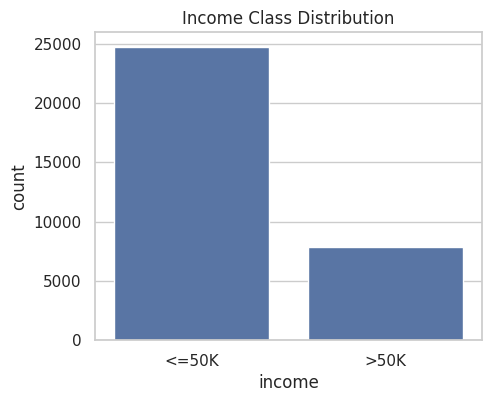

In [6]:
# Target variable distribution
print(df['income'].value_counts())
print(df['income'].value_counts(normalize=True) * 100)

plt.figure(figsize=(5,4))
sns.countplot(data=df, x='income')
plt.title('Income Class Distribution')
plt.show()


In [7]:
# Check for missing values represented as '?'
for col in df.select_dtypes(include='object').columns:
    n_q = (df[col] == '?').sum()
    if n_q > 0:
        print(f"{col}: {n_q} missing values marked as '?'")


workclass: 1836 missing values marked as '?'
occupation: 1843 missing values marked as '?'
native.country: 583 missing values marked as '?'


/tmp/ipykernel_585/1478563249.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


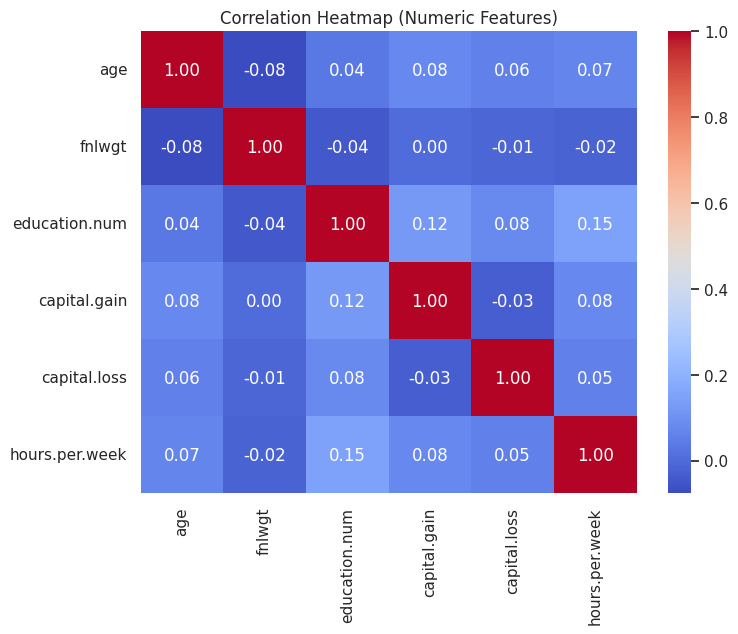

In [8]:
# Correlation heatmap for numeric features
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()


## Task 2: Data Cleaning 

In [9]:
# Work on a copy
data = df.copy()

# Replace '?' with NaN
data.replace('?', np.nan, inplace=True)

print("Missing values per column:")
print(data.isnull().sum()[data.isnull().sum() > 0])


Missing values per column:
workclass         1836
occupation        1843
native.country     583
dtype: int64


In [10]:
# Impute missing categorical values with the mode of each column
for col in ['workclass', 'occupation', 'native.country']:
    mode_val = data[col].mode()[0]
    data[col] = data[col].fillna(mode_val)

print("Missing values after imputation:")
print(data.isnull().sum().sum())


Missing values after imputation:
0


In [11]:
# Check and drop duplicate rows
print("Duplicate rows before:", data.duplicated().sum())
data.drop_duplicates(inplace=True)
print("Shape after dropping duplicates:", data.shape)


Duplicate rows before: 24
Shape after dropping duplicates: (32537, 15)


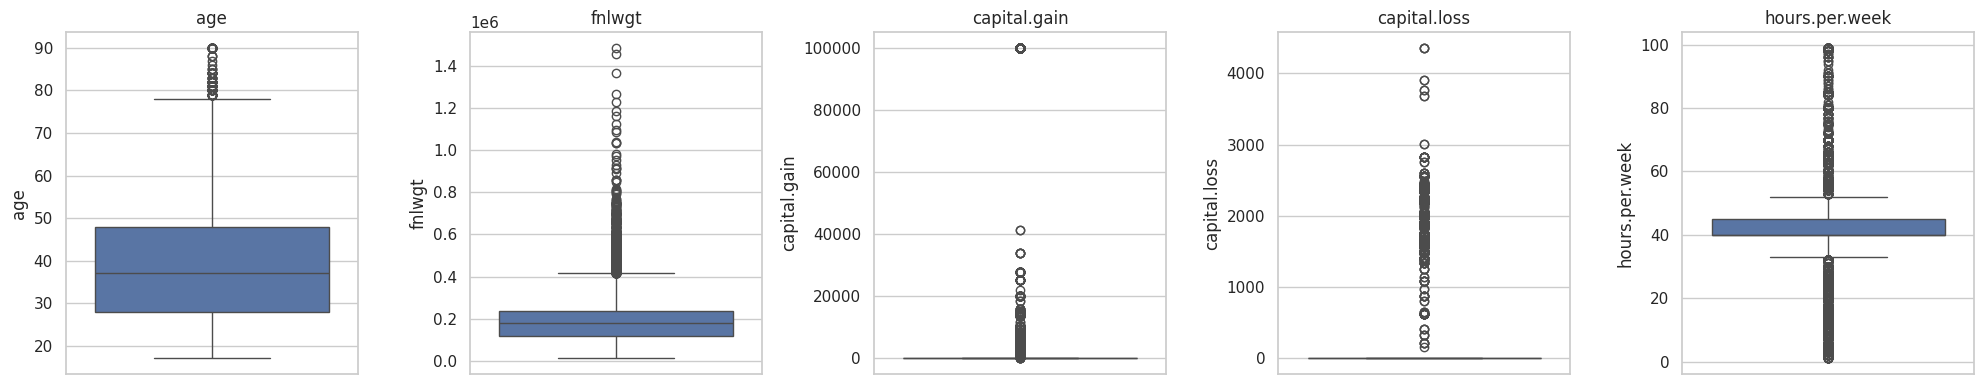

In [12]:
# Outlier check using boxplots for key numeric columns
num_cols = ['age', 'fnlwgt', 'capital.gain', 'capital.loss', 'hours.per.week']

fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=data[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [ ]:
# Cap extreme outliers in 'age' and 'hours.per.week' using the IQR method

def cap_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return series.clip(lower, upper)

for col in ['age', 'hours.per.week']:
    data[col] = cap_outliers_iqr(data[col])

print("Outlier capping done for 'age' and 'hours.per.week'.")


Outlier capping done for 'age' and 'hours.per.week'.


In [14]:
# Strip whitespace from string categorical columns (safety check)
obj_cols = data.select_dtypes(include='object').columns
for col in obj_cols:
    data[col] = data[col].str.strip()

data.head()


/tmp/ipykernel_585/4244840209.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = data.select_dtypes(include='object').columns


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,78,Private,77053,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40.0,United-States,<=50K
1,78,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,32.5,United-States,<=50K
2,66,Private,186061,Some-college,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40.0,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40.0,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40.0,United-States,<=50K


## Task 3: Feature Engineering

In [15]:
# Encode target variable: <=50K -> 0, >50K -> 1
data['income'] = data['income'].apply(lambda x: 1 if x.strip() == '>50K' else 0)
data['income'].value_counts()


income
0    24698
1     7839
Name: count, dtype: int64

In [16]:
# Drop 'education' since 'education.num' already encodes it numerically (redundant)
data.drop(columns=['education'], inplace=True)

# New feature: capital_net = capital.gain - capital.loss
data['capital_net'] = data['capital.gain'] - data['capital.loss']

# New feature: is_working_overtime (hours.per.week > 40)
data['is_overtime'] = (data['hours.per.week'] > 40).astype(int)

data.head()


,age,workclass,fnlwgt,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,capital_net,is_overtime
0,78,Private,77053,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40.0,United-States,0,-4356,0
1,78,Private,132870,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,32.5,United-States,0,-4356,0
2,66,Private,186061,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40.0,United-States,0,-4356,0
3,54,Private,140359,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40.0,United-States,0,-3900,0
4,41,Private,264663,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40.0,United-States,0,-3900,0


In [17]:
# Label-encode remaining categorical columns
cat_cols = data.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

data.head()


Categorical columns to encode: ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']


/tmp/ipykernel_585/1119506511.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data.select_dtypes(include='object').columns.tolist()


,age,workclass,fnlwgt,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,capital_net,is_overtime
0,78,3,77053,9,6,9,1,4,0,0,4356,40.0,38,0,-4356,0
1,78,3,132870,9,6,3,1,4,0,0,4356,32.5,38,0,-4356,0
2,66,3,186061,10,6,9,4,2,0,0,4356,40.0,38,0,-4356,0
3,54,3,140359,4,0,6,4,4,0,0,3900,40.0,38,0,-3900,0
4,41,3,264663,10,5,9,3,4,0,0,3900,40.0,38,0,-3900,0


In [18]:
# Split features / target
X = data.drop(columns=['income'])
y = data['income']

# Train-test split (stratified, since classes are imbalanced)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Feature scaling (important for KNN, SVM, Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (26029, 15)  Test shape: (6508, 15)


## Task 4: Model Building — Classification Algorithms 

We train the 5 algorithms required by the assignment:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors (KNN)
5. Support Vector Machine (SVM)


In [19]:
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), True),
    'Decision Tree':       (DecisionTreeClassifier(random_state=RANDOM_STATE), False),
    'Random Forest':       (RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE), False),
    'KNN':                 (KNeighborsClassifier(n_neighbors=5), True),
    'SVM':                 (SVC(probability=True, random_state=RANDOM_STATE), True),
}

trained_models = {}

for name, (model, needs_scaling) in models.items():
    Xtr = X_train_scaled if needs_scaling else X_train
    model.fit(Xtr, y_train)
    trained_models[name] = model
    print(f"{name} trained.")


Logistic Regression trained.


Decision Tree trained.


Random Forest trained.
KNN trained.


SVM trained.


## Task 5: Performance Evaluation 

In [20]:
results = []

for name, (model, needs_scaling) in models.items():
    Xte = X_test_scaled if needs_scaling else X_test
    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({
        'Algorithm': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    })

results_df = pd.DataFrame(results).set_index('Algorithm')
results_df


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Algorithm,,,,,
Logistic Regression,0.8245,0.7126,0.4554,0.5556,0.8508
Decision Tree,0.8007,0.5846,0.5969,0.5907,0.7312
Random Forest,0.8557,0.7384,0.6212,0.6747,0.9018
KNN,0.8245,0.6562,0.5708,0.6105,0.8410
SVM,0.8465,0.7561,0.5357,0.6271,0.8877


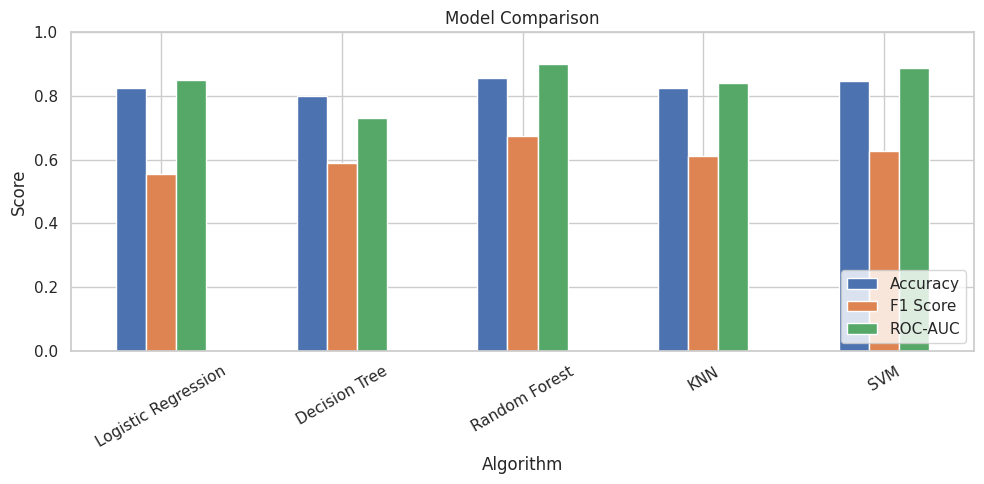

In [21]:
# Bar chart comparing Accuracy and F1 Score across models
results_df[['Accuracy', 'F1 Score', 'ROC-AUC']].plot(kind='bar', figsize=(10,5))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


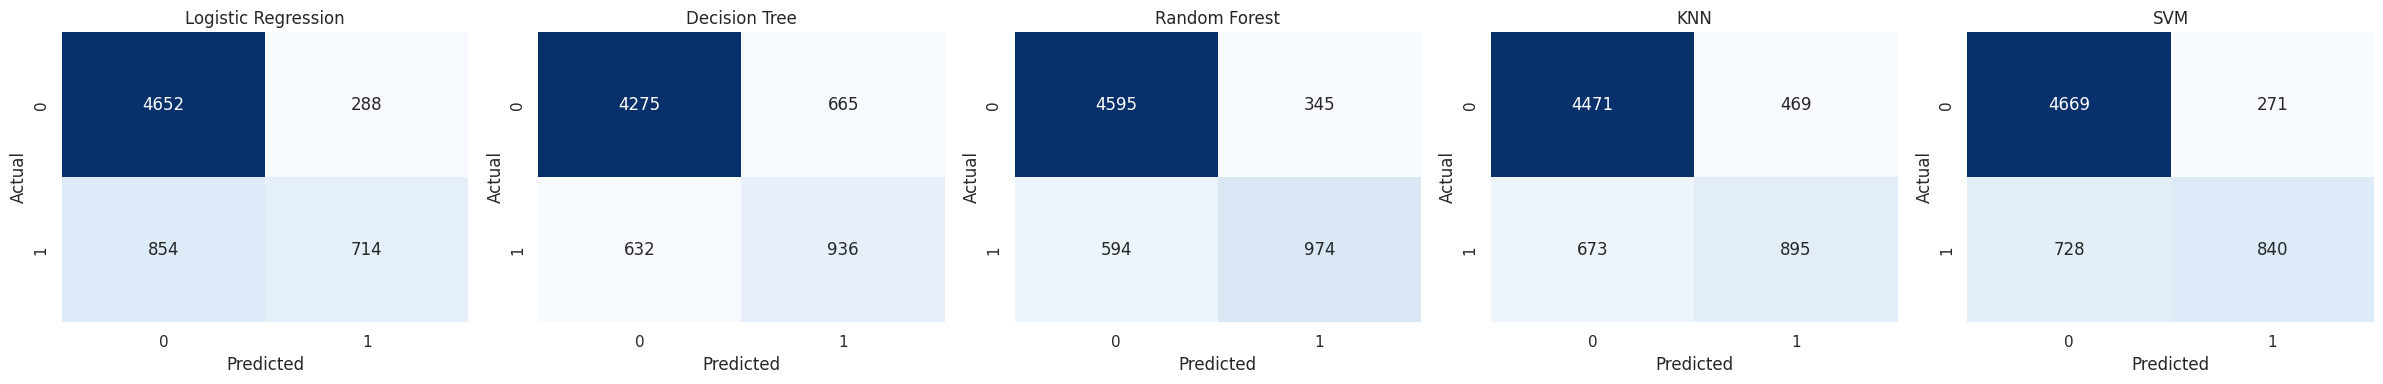

In [22]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 5, figsize=(24, 4))

for ax, (name, (model, needs_scaling)) in zip(axes, models.items()):
    Xte = X_test_scaled if needs_scaling else X_test
    y_pred = model.predict(Xte)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


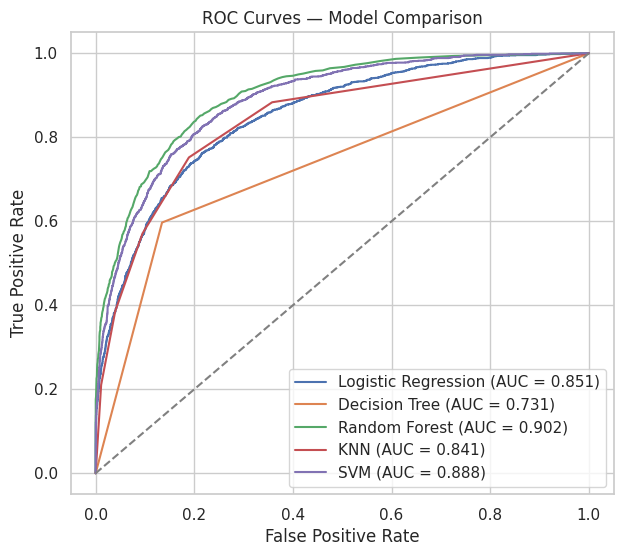

In [23]:
# ROC curves for all models
plt.figure(figsize=(7,6))

for name, (model, needs_scaling) in models.items():
    Xte = X_test_scaled if needs_scaling else X_test
    y_proba = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend(loc='lower right')
plt.show()


In [24]:
# Detailed classification report for the best model (by F1 Score)
best_model_name = results_df['F1 Score'].idxmax()
print(f"Best model by F1 Score: {best_model_name}\n")

model, needs_scaling = models[best_model_name]
Xte = X_test_scaled if needs_scaling else X_test
y_pred = model.predict(Xte)

print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))


Best model by F1 Score: Random Forest



              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      4940
        >50K       0.74      0.62      0.67      1568

    accuracy                           0.86      6508
   macro avg       0.81      0.78      0.79      6508
weighted avg       0.85      0.86      0.85      6508

